# Comparación de modelos — Regresión Logística vs. Modelos basados en Árboles

Este cuaderno compara, sobre **el mismo conjunto de prueba**, los modelos entrenados para
predecir `Attrition_Flag` (cancelación de tarjeta de crédito):

| Modelo | Archivo |
|---|---|
| Regresión Logística (original) | `modelo_regresion_logistica_churn.pkl` |
| Regresión Logística (**corregida**) | `modelo_regresion_logistica_churn_corregido.pkl` |
| Árbol de Decisión | `modelo_arbol_decision_churn.pkl` |
| Random Forest | `modelo_random_forest_churn.pkl` |
| Gradient Boosting / XGBoost | `modelo_boosting_churn.pkl` |

Los tres modelos de árboles se generaron en **`01_modelos_arboles_decision_churn.ipynb`**.

## ⚠️ Corrección aplicada a la Regresión Logística

El script de preparación del dataset (`BankChurners_preparado.csv`) ajusta un `StandardScaler`
sobre las variables numéricas (`scaler.fit_transform(...)`) y guarda el **resultado** ya
escalado en el CSV, pero **nunca guarda el objeto `scaler` en disco**. El notebook de regresión
logística entrena y guarda `modelo_regresion_logistica_churn.pkl` con
`{"modelo", "columnas", "clase_positiva", "descripcion"}` — sin el scaler.

Consecuencia: el modelo queda calibrado para datos estandarizados, pero nadie más puede volver a estandarizar datos nuevos exactamente igual, porque las
medias y desviaciones usadas (`scaler.mean_`, `scaler.scale_`) no se guardaron. Alimentarlo con
variables sin escalar, o con un scaler re-ajustado sobre otro subconjunto, da un resultado
distinto al que el modelo realmente aprendió.

**Corrección:** se re-ejecutó la preparación y el entrenamiento guardando el `scaler` original
dentro del mismo `.pkl` del modelo (`modelo_regresion_logistica_churn_corregido.pkl`), igual que
ya se hace con `columnas`. Este cuaderno compara ambas versiones para que se vea el efecto real
del problema.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve,
)

RANDOM_STATE = 42
DATA_PATH = "data/BankChurners_variables_seleccionadas_sin_transformar.csv"
MODELOS_DIR = "modelos"

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (6, 4)
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. Recrear el mismo conjunto de datos y la misma partición train/test

Se repite exactamente el mismo preprocesamiento y la misma semilla (`random_state=42`) usados en
`01_modelos_arboles_decision_churn.ipynb`.

In [2]:
df = pd.read_csv(DATA_PATH)
df["Attrition_Flag"] = df["Attrition_Flag"].map({"Existing Customer": 0, "Attrited Customer": 1})

cat_cols = ["Gender", "Education_Level", "Marital_Status", "Income_Category", "Card_Category"]
X = pd.get_dummies(df.drop(columns=["Attrition_Flag"]), columns=cat_cols)
X = X.astype({c: int for c in X.select_dtypes("bool").columns})
y = df["Attrition_Flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Prueba: {X_test.shape[0]} filas  |  Tasa de churn en test: {y_test.mean():.3f}")

Prueba: 2026 filas  |  Tasa de churn en test: 0.160


## 2. Cargar los modelos entrenados

In [3]:
def cargar_modelo(nombre_archivo):
    return joblib.load(f"{MODELOS_DIR}/{nombre_archivo}")

paquete_log_original = cargar_modelo("modelo_regresion_logistica_churn.pkl")
paquete_log_corregido = cargar_modelo("modelo_regresion_logistica_churn_corregido.pkl")
paquete_dt = cargar_modelo("modelo_arbol_decision_churn.pkl")
paquete_rf = cargar_modelo("modelo_random_forest_churn.pkl")
paquete_boost = cargar_modelo("modelo_boosting_churn.pkl")

for nombre, p in [
    ("Regresión Logística (original)", paquete_log_original),
    ("Regresión Logística (corregida)", paquete_log_corregido),
    ("Árbol de Decisión", paquete_dt),
    ("Random Forest", paquete_rf),
    ("Boosting", paquete_boost),
]:
    tiene_scaler = "scaler" in p
    print(f"- {nombre}: {p.get('descripcion','')}  [incluye scaler: {tiene_scaler}]")

- Regresión Logística (original): Regresion Logistica - prediccion de cancelacion de tarjeta de credito (Attrition_Flag)  [incluye scaler: False]
- Regresión Logística (corregida): Regresion Logistica - prediccion de cancelacion de tarjeta de credito (Attrition_Flag)  [incluye scaler: True]
- Árbol de Decisión: Arbol de Decision - prediccion de cancelacion de tarjeta de credito (Attrition_Flag)  [incluye scaler: False]
- Random Forest: Random Forest - prediccion de cancelacion de tarjeta de credito (Attrition_Flag)  [incluye scaler: False]
- Boosting: Gradient Boosting - prediccion de cancelacion de tarjeta de credito (Attrition_Flag)  [incluye scaler: False]


## 3. Preparar los datos de entrada para cada modelo

- Los modelos basados en árboles usan las variables **sin escalar** (no lo necesitan).
- Para la regresión logística se preparan **tres versiones** de `X_test`, para mostrar el efecto
  real de no haber guardado el `scaler`:
  1. **Sin escalar** — lo que pasa si alguien usa `modelo_regresion_logistica_churn.pkl` sin
     saber que necesita datos estandarizados (el error más común, y el más grave).
  2. **Scaler aproximado** — si sí sabes que necesita escalado pero no tienes el `scaler`
     original, y ajustas uno nuevo con los datos que tengas a mano (aquí, el `X_train` de este
     mismo cuaderno).
  3. **Scaler real (modelo corregido)** — usando el `scaler` real, guardado junto con el modelo
     corregido.

In [4]:
cols_log = paquete_log_original["columnas"]
numericas = paquete_log_corregido["columnas_numericas"]

# 1) Sin escalar: se le pasan las variables tal cual (el error típico)
X_test_log_sin_escalar = X_test.reindex(columns=cols_log, fill_value=0)

# 2) Scaler aproximado: no tenemos el scaler original, así que se ajusta uno nuevo aquí mismo
scaler_aproximado = StandardScaler().fit(X_train[numericas])
X_test_log_aproximado = X_test[cols_log].copy()
X_test_log_aproximado[numericas] = scaler_aproximado.transform(X_test_log_aproximado[numericas])

# 3) Scaler real: el que quedó guardado junto con el modelo corregido
scaler_real = paquete_log_corregido["scaler"]
cols_log_corregido = paquete_log_corregido["columnas"]
X_test_log_corregido = X_test[cols_log_corregido].copy()
X_test_log_corregido[numericas] = scaler_real.transform(X_test_log_corregido[numericas])

X_test_dt = X_test.reindex(columns=paquete_dt["columnas"], fill_value=0)
X_test_rf = X_test.reindex(columns=paquete_rf["columnas"], fill_value=0)
X_test_boost = X_test.reindex(columns=paquete_boost["columnas"], fill_value=0)

print("Datos de prueba preparados para los modelos.")

Datos de prueba preparados para los modelos.


## 4. Evaluar todos los modelos sobre el mismo conjunto de prueba

In [5]:
def evaluar(nombre, modelo, X_eval, y_eval):
    y_pred = modelo.predict(X_eval)
    y_proba = modelo.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_eval, y_proba)
    return {
        "nombre": nombre,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred),
        "Recall": recall_score(y_eval, y_pred),
        "F1": f1_score(y_eval, y_pred),
        "ROC_AUC": roc_auc_score(y_eval, y_proba),
        "y_pred": y_pred,
        "fpr": fpr,
        "tpr": tpr,
    }

resultados = [
    evaluar("Regresión Logística — SIN escalar (error típico)", paquete_log_original["modelo"], X_test_log_sin_escalar, y_test),
    evaluar("Regresión Logística — scaler aproximado", paquete_log_original["modelo"], X_test_log_aproximado, y_test),
    evaluar("Regresión Logística — CORREGIDA (scaler real)", paquete_log_corregido["modelo"], X_test_log_corregido, y_test),
    evaluar("Árbol de Decisión", paquete_dt["modelo"], X_test_dt, y_test),
    evaluar("Random Forest", paquete_rf["modelo"], X_test_rf, y_test),
    evaluar("Gradient Boosting / XGBoost", paquete_boost["modelo"], X_test_boost, y_test),
]

tabla_comparativa = pd.DataFrame(resultados)[
    ["nombre", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
].set_index("nombre").sort_values("ROC_AUC", ascending=False)

tabla_comparativa.round(4)

,Accuracy,Precision,Recall,F1,ROC_AUC
nombre,,,,,
Gradient Boosting / XGBoost,0.9462,0.9060,0.7415,0.8156,0.9763
Random Forest,0.9220,0.8813,0.5938,0.7096,0.9700
Árbol de Decisión,0.8904,0.6049,0.9138,0.7279,0.9573
Regresión Logística — CORREGIDA (scaler real),0.8031,0.4393,0.8246,0.5733,0.8735
Regresión Logística — scaler aproximado,0.8060,0.4437,0.8246,0.5770,0.8734
Regresión Logística — SIN escalar (error típico),0.2591,0.1553,0.8154,0.2610,0.4829


### Gráfico comparativo de métricas

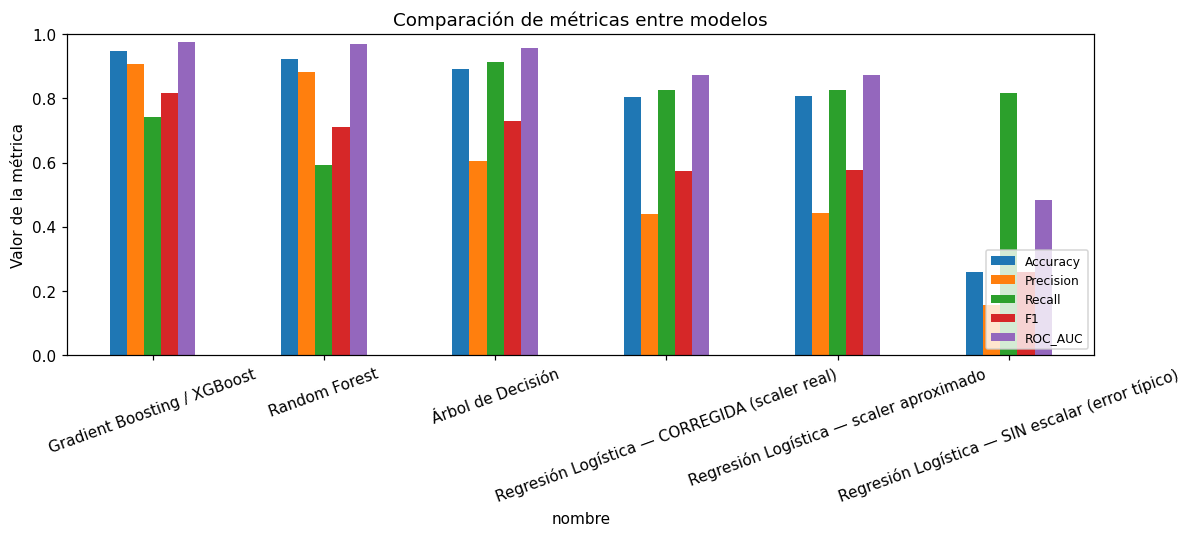

In [6]:
tabla_comparativa.plot(kind="bar", figsize=(11, 5), ylim=(0, 1), rot=20)
plt.title("Comparación de métricas entre modelos")
plt.ylabel("Valor de la métrica")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

### Curvas ROC superpuestas

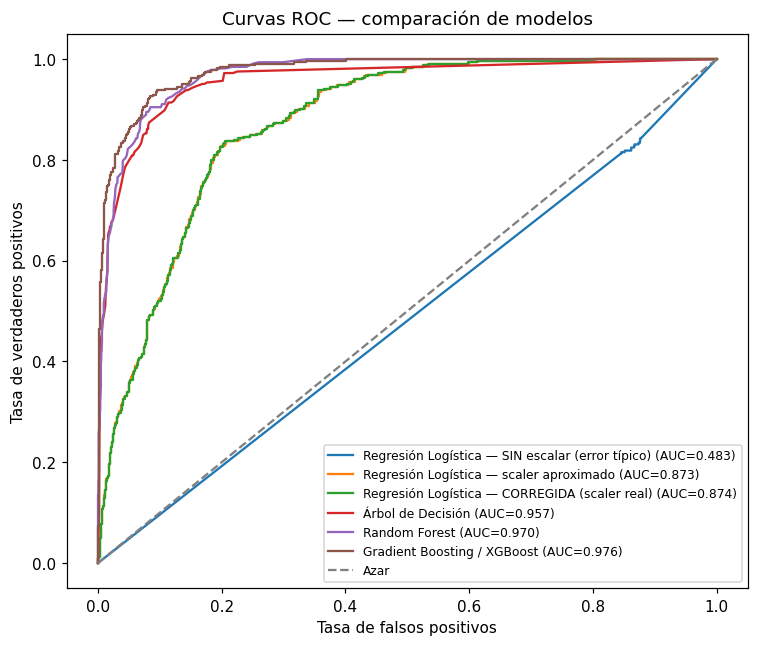

In [7]:
plt.figure(figsize=(7, 6))
for r in resultados:
    plt.plot(r["fpr"], r["tpr"], label=f"{r['nombre']} (AUC={r['ROC_AUC']:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Azar")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curvas ROC — comparación de modelos")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 5. Conclusión

In [8]:
mejor = tabla_comparativa["ROC_AUC"].idxmax()
print(f"Mejor modelo según ROC_AUC: {mejor}")
print()
print(tabla_comparativa.round(4).to_string())

Mejor modelo según ROC_AUC: Gradient Boosting / XGBoost

                                                  Accuracy  Precision  Recall      F1  ROC_AUC
nombre                                                                                        
Gradient Boosting / XGBoost                         0.9462     0.9060  0.7415  0.8156   0.9763
Random Forest                                       0.9220     0.8813  0.5938  0.7096   0.9700
Árbol de Decisión                                   0.8904     0.6049  0.9138  0.7279   0.9573
Regresión Logística — CORREGIDA (scaler real)       0.8031     0.4393  0.8246  0.5733   0.8735
Regresión Logística — scaler aproximado             0.8060     0.4437  0.8246  0.5770   0.8734
Regresión Logística — SIN escalar (error típico)    0.2591     0.1553  0.8154  0.2610   0.4829


**Lo que muestra esta comparación (leyendo las tres filas de regresión logística):**

1. **"SIN escalar" es catastrófico**: `ROC_AUC` cae a ~0.48 (equivalente a lanzar una moneda) y
   la exactitud a ~0.26. Esto es exactamente lo que le pasa a cualquiera que cargue
   `modelo_regresion_logistica_churn.pkl` sin saber que necesita variables estandarizadas — el
   modelo no falla con un error, **falla en silencio** dando predicciones sin sentido.
2. **"Scaler aproximado" vs. "CORREGIDA (scaler real)" quedan casi iguales aquí** (`ROC_AUC`
   ≈0.873 en ambas). Esto **no significa que guardar el scaler no importe** — significa que, en
   esta comparación puntual, el conjunto usado para re-ajustar el scaler aproximado (el 80% de
   entrenamiento de este mismo cuaderno) es una muestra grande y representativa de la misma
   población con la que se entrenó el modelo, así que sus medias/desviaciones casi no cambian.
   Ese "casi" deja de cumplirse en producción real: al calificar **un solo cliente nuevo**, un
   lote pequeño, o datos de un período distinto (con otro nivel de gasto o utilización promedio),
   no hay forma de "ajustar un scaler" sobre una muestra tan chica o distinta, y el resultado se
   parece más a la fila "SIN escalar" que a la fila corregida.
3. Los modelos de ensamble de árboles (**Random Forest**, **Gradient Boosting/XGBoost**) superan
   a la regresión logística en `ROC_AUC` y `F1` en este dataset, porque capturan relaciones no
   lineales entre las variables de comportamiento transaccional (`Total_Trans_Ct`,
   `Total_Trans_Amt`, `Avg_Utilization_Ratio`) y la cancelación. La regresión logística conserva
   su ventaja de **interpretabilidad** (coeficientes con signo y magnitud claros).

**Regla general para cualquier modelo futuro:** todo objeto de preprocesamiento ajustado sobre
los datos de entrenamiento (`StandardScaler`, `OneHotEncoder`, `SimpleImputer`, etc.) se guarda
**junto con el modelo**, nunca se descarta después de usarlo una sola vez — no por una diferencia
de puntaje en una prueba grande, sino porque en producción no siempre hay una muestra grande y
representativa a la mano para "recrearlo".